## Model Building Code

In [80]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [81]:
X_train_pad = np.load("X_train_pad.npy")
X_test_pad = np.load("X_test_pad.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Classes:", label_encoder.classes_)

X_train shape: (40852, 150)
X_test shape: (10214, 150)
y_train shape: (40852,)
y_test shape: (10214,)
Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [82]:
max_words = 20000
max_len = 150
num_classes = len(label_encoder.classes_)

embedding_dim = 128
lstm_units = 64
dropout_rate = 0.5
batch_size = 32
epochs = 10

print("Number of classes:", num_classes)

Number of classes: 7


| Parameter       | Selected value | Reason                                            |
| --------------- | -------------: | ------------------------------------------------- |
| `max_words`     |         20,000 | Limits vocabulary size for manageable training    |
| `max_len`       |            150 | Based on EDA percentile and training practicality |
| `embedding_dim` |            128 | Common starting value for text classification     |
| `lstm_units`    |             64 | Balanced model complexity                         |
| `dropout_rate`  |            0.5 | Helps reduce overfitting                          |
| `batch_size`    |             32 | Standard stable training size                     |
| `epochs`        |             10 | Enough for baseline, with early stopping          |


In [83]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_table = pd.DataFrame({
    "Class Index": list(class_weight_dict.keys()),
    "Class Name": label_encoder.classes_,
    "Class Weight": list(class_weight_dict.values())
})

class_weight_table

,Class Index,Class Name,Class Weight
0,0,Anxiety,2.016586
1,1,Bipolar,2.916542
2,2,Depression,0.483553
3,3,Normal,0.455013
4,4,Personality disorder,8.150838
5,5,Stress,3.182116
6,6,Suicidal,0.685620


In [84]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

## Model 1: Baseline LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len),
    LSTM(units=lstm_units),
    Dropout(dropout_rate),
    Dense(64,activation="relu"),
    Dropout(dropout_rate),
    Dense(num_classes,activation="softmax")
])
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
lstm_model.summary()

c:\Users\irfan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [94]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.2793 - loss: 1.8959 - val_accuracy: 0.3532 - val_loss: 1.8446
Epoch 2/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.3084 - loss: 1.8528 - val_accuracy: 0.3931 - val_loss: 1.7995
Epoch 3/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.3384 - loss: 1.8088 - val_accuracy: 0.3363 - val_loss: 1.9238
Epoch 4/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.3988 - loss: 1.6427 - val_accuracy: 0.5162 - val_loss: 1.2432
Epoch 5/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.5241 - loss: 1.3424 - val_accuracy: 0.5532 - val_loss: 1.0849
Epoch 6/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.5761 - loss: 1.0842 - val_accuracy: 0.6003 - val_loss: 0.9474
Epoch 7/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.6281 - loss: 0.8882 - val_accuracy: 0.6234 - val_loss: 0.8812
Epoch 8/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.6667 -

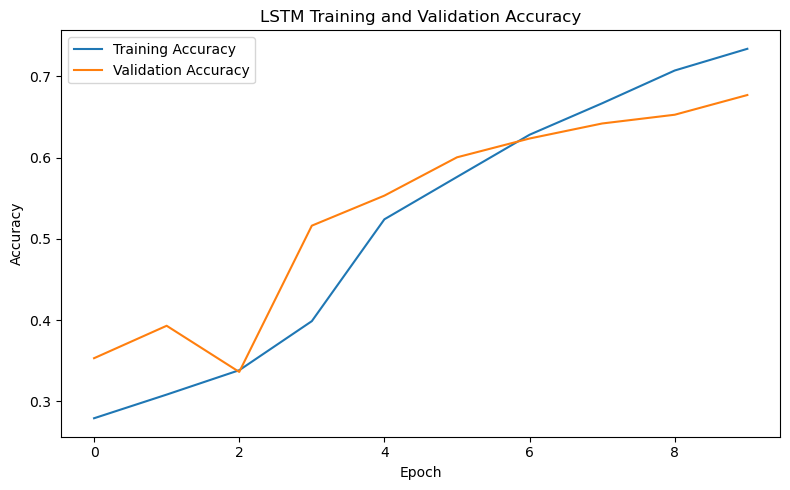

In [104]:
plt.figure(figsize=(8, 5))
plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

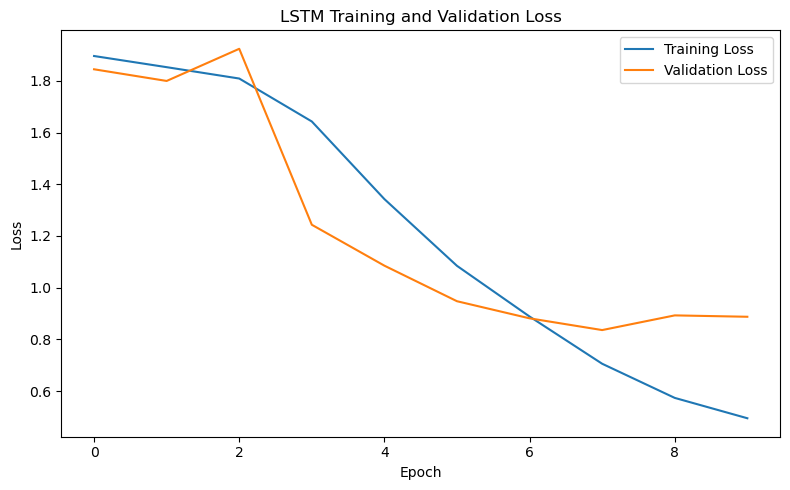

In [105]:
plt.figure(figsize=(8, 5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [106]:
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(X_test_pad, y_test, verbose=0)

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Accuracy:", round(lstm_test_accuracy, 4))

LSTM Test Loss: 0.8527
LSTM Test Accuracy: 0.6333


In [107]:
lstm_y_pred_prob = lstm_model.predict(X_test_pad)
lstm_y_pred = np.argmax(lstm_y_pred_prob, axis=1)

print("LSTM Classification Report:")
print(classification_report(
    y_test,
    lstm_y_pred,
    target_names=label_encoder.classes_
))

320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
LSTM Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.69      0.68      0.69       723
             Bipolar       0.72      0.71      0.72       500
          Depression       0.64      0.25      0.36      3018
              Normal       0.94      0.87      0.91      3207
Personality disorder       0.43      0.45      0.44       179
              Stress       0.28      0.68      0.40       459
            Suicidal       0.47      0.80      0.59      2128

            accuracy                           0.63     10214
           macro avg       0.60      0.63      0.58     10214
        weighted avg       0.69      0.63      0.62     10214



In [109]:
lstm_cm = confusion_matrix(y_test, lstm_y_pred)

lstm_cm_df = pd.DataFrame(
    lstm_cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

lstm_cm_df

,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,492,19,28,13,6,150,15
Bipolar,13,353,23,4,15,78,14
Depression,75,72,740,69,54,276,1732
Normal,57,8,21,2792,16,197,116
Personality disorder,4,12,24,7,80,40,12
Stress,59,12,42,5,4,310,27
Suicidal,10,11,270,66,13,56,1702


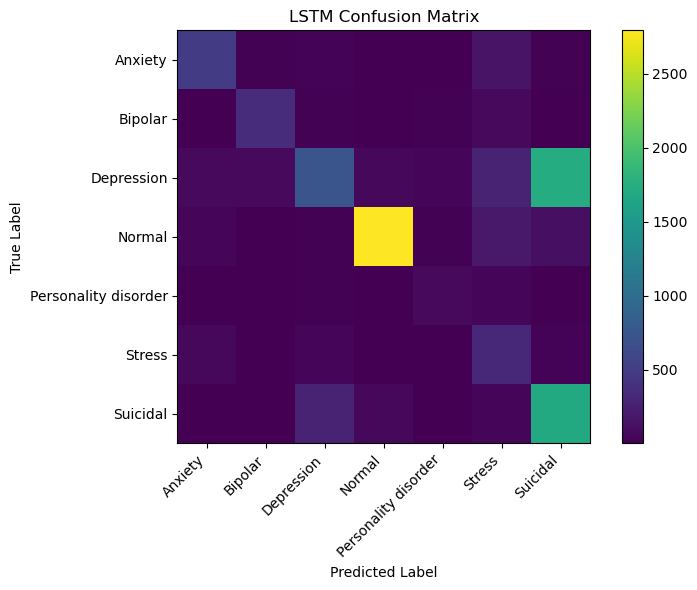

In [110]:
plt.figure(figsize=(8, 6))
plt.imshow(lstm_cm, interpolation="nearest")
plt.title("LSTM Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Model 2: Baseline BiLSTM

In [87]:
bilstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        input_length=max_len
    ),
    
    Bidirectional(
        LSTM(units=lstm_units)
    ),
    
    Dropout(dropout_rate),
    
    Dense(
        64,
        activation="relu"
    ),
    
    Dropout(dropout_rate),
    
    Dense(
        num_classes,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stopping_bilstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping_bilstm],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7746 - loss: 0.4376 - val_accuracy: 0.7009 - val_loss: 0.8613
Epoch 2/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7928 - loss: 0.3871 - val_accuracy: 0.7090 - val_loss: 0.8762
Epoch 3/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.8385 - loss: 0.3039 - val_accuracy: 0.7177 - val_loss: 0.9056


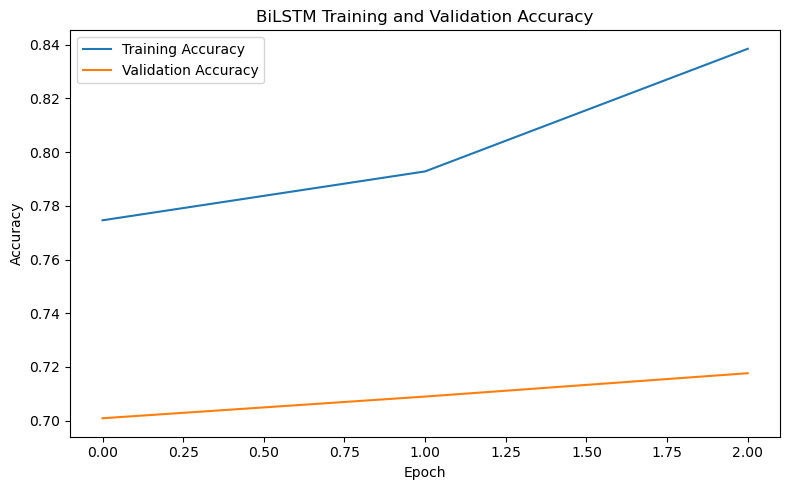

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(bilstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(bilstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

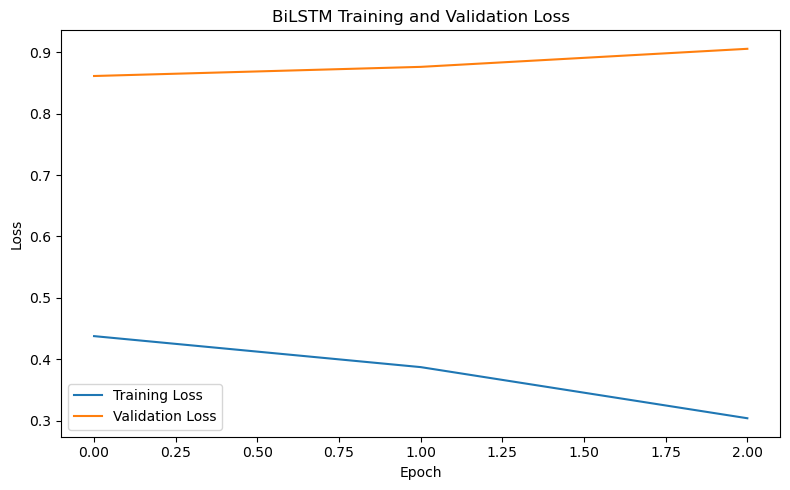

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(bilstm_history.history["loss"], label="Training Loss")
plt.plot(bilstm_history.history["val_loss"], label="Validation Loss")
plt.title("BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(X_test_pad, y_test, verbose=0)

print("BiLSTM Test Loss:", round(bilstm_test_loss, 4))
print("BiLSTM Test Accuracy:", round(bilstm_test_accuracy, 4))

BiLSTM Test Loss: 0.8339
BiLSTM Test Accuracy: 0.7031


In [101]:
bilstm_y_pred_prob = bilstm_model.predict(X_test_pad)
bilstm_y_pred = np.argmax(bilstm_y_pred_prob, axis=1)

print("BiLSTM Classification Report:")
print(classification_report(
    y_test,
    bilstm_y_pred,
    target_names=label_encoder.classes_
))

320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
BiLSTM Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.76      0.77      0.76       723
             Bipolar       0.65      0.72      0.68       500
          Depression       0.71      0.46      0.56      3018
              Normal       0.93      0.91      0.92      3207
Personality disorder       0.32      0.61      0.42       179
              Stress       0.39      0.58      0.47       459
            Suicidal       0.57      0.75      0.65      2128

            accuracy                           0.70     10214
           macro avg       0.62      0.68      0.64     10214
        weighted avg       0.73      0.70      0.70     10214



In [102]:
bilstm_cm = confusion_matrix(y_test, bilstm_y_pred)

bilstm_cm_df = pd.DataFrame(
    bilstm_cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

bilstm_cm_df

,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,556,44,21,18,24,56,4
Bipolar,22,360,37,11,32,34,4
Depression,71,86,1382,76,92,188,1123
Normal,37,7,53,2912,33,90,75
Personality disorder,3,15,25,8,109,11,8
Stress,37,29,60,28,30,264,11
Suicidal,7,17,372,85,18,31,1598


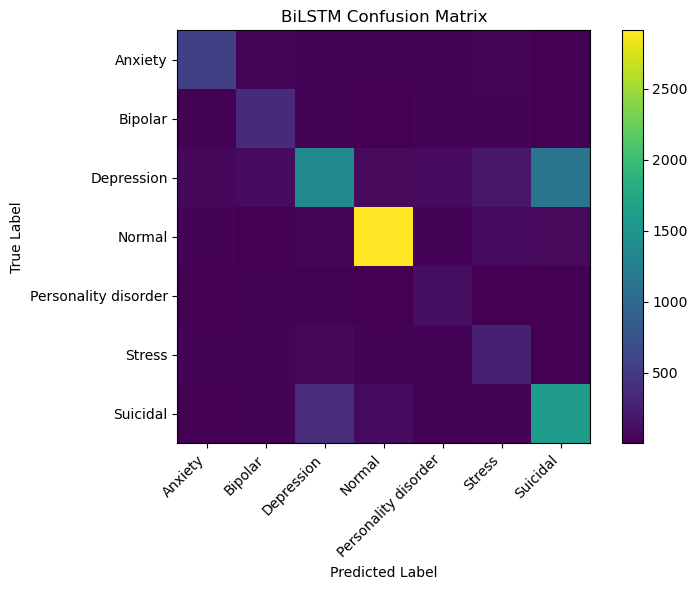

In [103]:
plt.figure(figsize=(8, 6))
plt.imshow(bilstm_cm, interpolation="nearest")
plt.title("BiLSTM Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Baseline Model Comparison

In [111]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

lstm_metrics = get_metrics(y_test, lstm_y_pred)
bilstm_metrics = get_metrics(y_test, bilstm_y_pred)

baseline_comparison = pd.DataFrame([
    {
        "Model": "LSTM",
        "Test Loss": round(lstm_test_loss, 4),
        "Accuracy": round(lstm_metrics["Accuracy"], 4),
        "Precision": round(lstm_metrics["Precision"], 4),
        "Recall": round(lstm_metrics["Recall"], 4),
        "F1-score": round(lstm_metrics["F1-score"], 4)
    },
    {
        "Model": "BiLSTM",
        "Test Loss": round(bilstm_test_loss, 4),
        "Accuracy": round(bilstm_metrics["Accuracy"], 4),
        "Precision": round(bilstm_metrics["Precision"], 4),
        "Recall": round(bilstm_metrics["Recall"], 4),
        "F1-score": round(bilstm_metrics["F1-score"], 4)
    }
])

baseline_comparison

,Model,Test Loss,Accuracy,Precision,Recall,F1-score
0,LSTM,0.8527,0.6333,0.6896,0.6333,0.6219
1,BiLSTM,0.8339,0.7031,0.7272,0.7031,0.7028


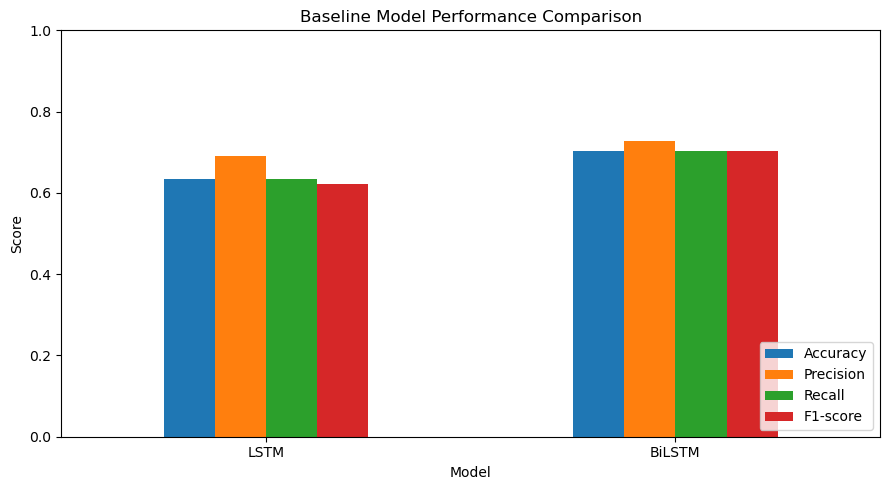

In [112]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

baseline_comparison_plot = baseline_comparison.set_index("Model")[metrics_to_plot]

baseline_comparison_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Tuned BiLSTM

In [114]:
import numpy as np
import pandas as pd
import pickle
import shutil
import os
import matplotlib.pyplot as plt

import tensorflow as tf
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)

TensorFlow: 2.21.0
Keras Tuner: 1.4.8


In [115]:
X_train_pad = np.load("X_train_pad.npy")
X_test_pad = np.load("X_test_pad.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("X_train:", X_train_pad.shape)
print("X_test:", X_test_pad.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Classes:", label_encoder.classes_)

X_train: (40852, 150)
X_test: (10214, 150)
y_train: (40852,)
y_test: (10214,)
Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [116]:
max_words = 20000
max_len = 150
num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)

Number of classes: 7


In [117]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_table = pd.DataFrame({
    "Class Index": list(class_weight_dict.keys()),
    "Class Name": label_encoder.classes_,
    "Class Weight": list(class_weight_dict.values())
})

class_weight_table

,Class Index,Class Name,Class Weight
0,0,Anxiety,2.016586
1,1,Bipolar,2.916542
2,2,Depression,0.483553
3,3,Normal,0.455013
4,4,Personality disorder,8.150838
5,5,Stress,3.182116
6,6,Suicidal,0.685620


In [118]:
def build_bilstm_tuned_model(hp):
    model = Sequential()
    
    embedding_dim = hp.Choice(
        "embedding_dim",
        values=[64, 128, 256]
    )
    
    model.add(
        Embedding(
            input_dim=max_words,
            output_dim=embedding_dim,
            input_length=max_len
        )
    )
    
    lstm_units = hp.Choice(
        "bilstm_units",
        values=[32, 64, 128]
    )
    
    recurrent_dropout = hp.Choice(
        "recurrent_dropout",
        values=[0.0, 0.2]
    )
    
    model.add(
        Bidirectional(
            LSTM(
                units=lstm_units,
                recurrent_dropout=recurrent_dropout
            )
        )
    )
    
    dropout_rate = hp.Choice(
        "dropout_rate",
        values=[0.3, 0.4, 0.5]
    )
    
    model.add(Dropout(dropout_rate))
    
    dense_units = hp.Choice(
        "dense_units",
        values=[32, 64, 128]
    )
    
    model.add(
        Dense(
            units=dense_units,
            activation="relu"
        )
    )
    
    model.add(Dropout(dropout_rate))
    
    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )
    
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [119]:
tuner_dir = "keras_tuner_results_bilstm"

if os.path.exists(tuner_dir):
    shutil.rmtree(tuner_dir)
    print("Old BiLSTM tuner directory removed.")
else:
    print("No old BiLSTM tuner directory found.")

Old BiLSTM tuner directory removed.


In [120]:
bilstm_tuner = kt.RandomSearch(
    build_bilstm_tuned_model,
    objective="val_accuracy",
    max_trials=8,
    executions_per_trial=1,
    directory="keras_tuner_results_bilstm",
    project_name="mental_health_bilstm_tuning",
    overwrite=True
)

bilstm_tuner.search_space_summary()

Search space summary
Default search space size: 6
embedding_dim (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
bilstm_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
recurrent_dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.2], 'ordered': True}
dropout_rate (Choice)
{'default': 0.3, 'conditions': [], 'values': [0.3, 0.4, 0.5], 'ordered': True}
dense_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


c:\Users\irfan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [121]:
early_stopping_tuning = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

bilstm_tuner.search(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=32,
    callbacks=[early_stopping_tuning],
    class_weight=class_weight_dict,
    verbose=1
)

Trial 8 Complete [00h 11m 07s]
val_accuracy: 0.5913596749305725

Best val_accuracy So Far: 0.7192510366439819
Total elapsed time: 01h 38m 55s


In [122]:
bilstm_tuner.results_summary(num_trials=8)

Results summary
Results in keras_tuner_results_bilstm\mental_health_bilstm_tuning
Showing 8 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
embedding_dim: 128
bilstm_units: 32
recurrent_dropout: 0.0
dropout_rate: 0.3
dense_units: 64
learning_rate: 0.001
Score: 0.7192510366439819

Trial 4 summary
Hyperparameters:
embedding_dim: 256
bilstm_units: 128
recurrent_dropout: 0.2
dropout_rate: 0.5
dense_units: 128
learning_rate: 0.001
Score: 0.7073797583580017

Trial 0 summary
Hyperparameters:
embedding_dim: 64
bilstm_units: 64
recurrent_dropout: 0.0
dropout_rate: 0.4
dense_units: 64
learning_rate: 0.001
Score: 0.6945294141769409

Trial 6 summary
Hyperparameters:
embedding_dim: 64
bilstm_units: 128
recurrent_dropout: 0.0
dropout_rate: 0.3
dense_units: 64
learning_rate: 0.0005
Score: 0.6732345819473267

Trial 5 summary
Hyperparameters:
embedding_dim: 128
bilstm_units: 128
recurrent_dropout: 0.2
dropout_rate: 0.3
dense_units: 32
learning_rate: 0.001
S

In [123]:
best_bilstm_hps = bilstm_tuner.get_best_hyperparameters(num_trials=1)[0]

best_bilstm_hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "embedding_dim",
        "bilstm_units",
        "recurrent_dropout",
        "dropout_rate",
        "dense_units",
        "learning_rate"
    ],
    "Best Value": [
        best_bilstm_hps.get("embedding_dim"),
        best_bilstm_hps.get("bilstm_units"),
        best_bilstm_hps.get("recurrent_dropout"),
        best_bilstm_hps.get("dropout_rate"),
        best_bilstm_hps.get("dense_units"),
        best_bilstm_hps.get("learning_rate")
    ]
})

best_bilstm_hyperparameters

,Hyperparameter,Best Value
0,embedding_dim,128.000
1,bilstm_units,32.000
2,recurrent_dropout,0.000
3,dropout_rate,0.300
4,dense_units,64.000
5,learning_rate,0.001


In [124]:
tuned_bilstm_model = bilstm_tuner.hypermodel.build(best_bilstm_hps)

tuned_bilstm_model.summary()

c:\Users\irfan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [125]:
early_stopping_final = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

tuned_bilstm_history = tuned_bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping_final],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.5118 - loss: 1.4139 - val_accuracy: 0.5933 - val_loss: 0.9458
Epoch 2/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.6390 - loss: 0.8758 - val_accuracy: 0.6431 - val_loss: 0.8173
Epoch 3/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.6776 - loss: 0.7282 - val_accuracy: 0.6604 - val_loss: 0.8342
Epoch 4/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.7367 - loss: 0.5151 - val_accuracy: 0.6889 - val_loss: 0.8056
Epoch 5/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.7837 - loss: 0.3862 - val_accuracy: 0.7079 - val_loss: 0.8278
Epoch 6/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - accuracy: 0.8171 - loss: 0.3337 - val_accuracy: 0.7080 - val_loss: 0.8957
Epoch 7/10
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.8461 - loss: 0.2792 - val_accuracy: 0.7042 - val_loss: 0.9377


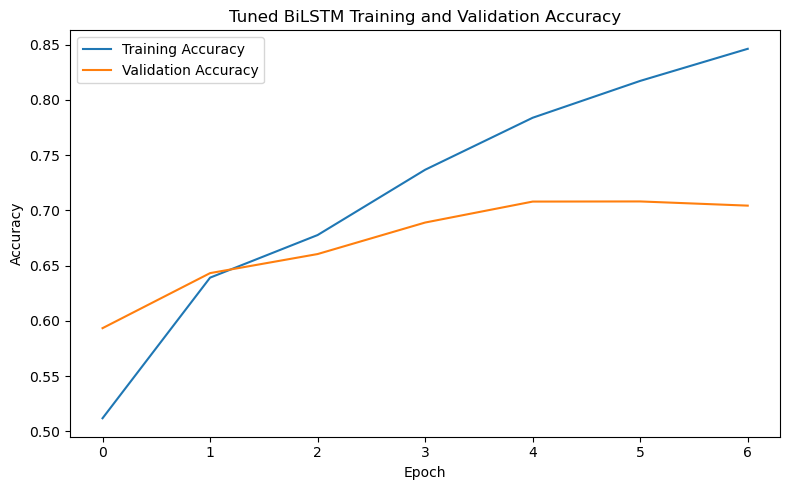

In [126]:
plt.figure(figsize=(8, 5))
plt.plot(tuned_bilstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(tuned_bilstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Tuned BiLSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

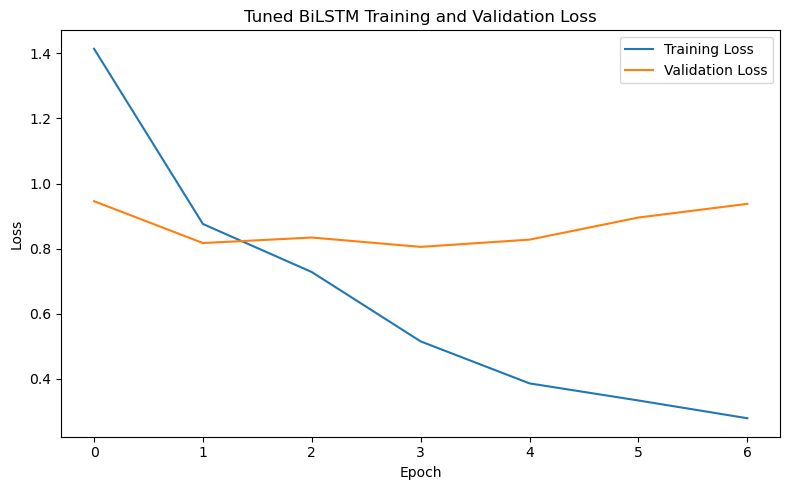

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(tuned_bilstm_history.history["loss"], label="Training Loss")
plt.plot(tuned_bilstm_history.history["val_loss"], label="Validation Loss")
plt.title("Tuned BiLSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [128]:
tuned_bilstm_test_loss, tuned_bilstm_test_accuracy = tuned_bilstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Tuned BiLSTM Test Loss:", round(tuned_bilstm_test_loss, 4))
print("Tuned BiLSTM Test Accuracy:", round(tuned_bilstm_test_accuracy, 4))

Tuned BiLSTM Test Loss: 0.803
Tuned BiLSTM Test Accuracy: 0.6856


In [129]:
tuned_bilstm_y_pred_prob = tuned_bilstm_model.predict(X_test_pad)
tuned_bilstm_y_pred = np.argmax(tuned_bilstm_y_pred_prob, axis=1)

print("Tuned BiLSTM Classification Report:")
print(classification_report(
    y_test,
    tuned_bilstm_y_pred,
    target_names=label_encoder.classes_
))

320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Tuned BiLSTM Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.76      0.73      0.74       723
             Bipolar       0.61      0.71      0.65       500
          Depression       0.71      0.40      0.51      3018
              Normal       0.92      0.90      0.91      3207
Personality disorder       0.32      0.58      0.41       179
              Stress       0.39      0.67      0.49       459
            Suicidal       0.54      0.76      0.63      2128

            accuracy                           0.69     10214
           macro avg       0.61      0.68      0.62     10214
        weighted avg       0.72      0.69      0.68     10214



In [130]:
tuned_bilstm_cm = confusion_matrix(y_test, tuned_bilstm_y_pred)

tuned_bilstm_cm_df = pd.DataFrame(
    tuned_bilstm_cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

tuned_bilstm_cm_df

,Anxiety,Bipolar,Depression,Normal,Personality disorder,Stress,Suicidal
Anxiety,527,46,25,17,18,88,2
Bipolar,21,355,32,7,34,45,6
Depression,66,120,1204,87,108,167,1266
Normal,39,9,27,2894,19,133,86
Personality disorder,11,9,24,6,103,19,7
Stress,27,30,31,18,24,309,20
Suicidal,3,17,352,100,14,31,1611


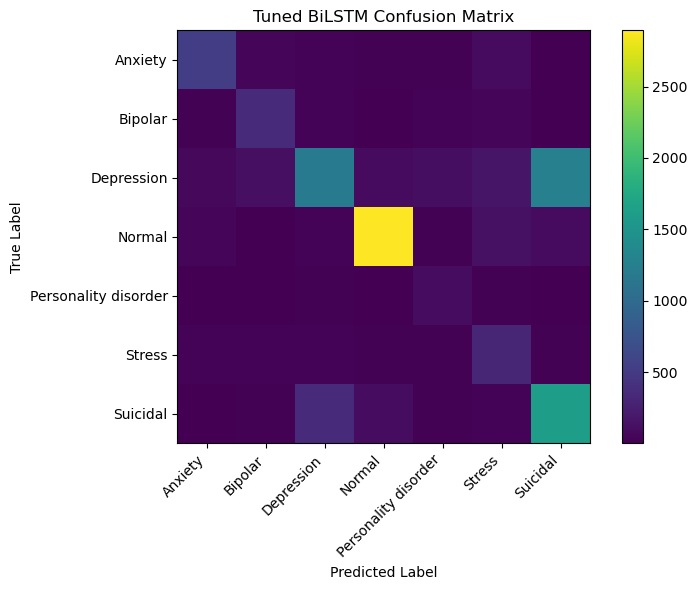

In [131]:
plt.figure(figsize=(8, 6))
plt.imshow(tuned_bilstm_cm, interpolation="nearest")
plt.title("Tuned BiLSTM Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Final Comparison

In [132]:
# Calculate tuned BiLSTM performance metrics
tuned_bilstm_metrics = get_metrics(y_test, tuned_bilstm_y_pred)

# Create final model comparison table
final_model_comparison = pd.DataFrame([
    {
        "Model": "Baseline LSTM",
        "Test Loss": round(lstm_test_loss, 4),
        "Accuracy": round(lstm_metrics["Accuracy"], 4),
        "Precision": round(lstm_metrics["Precision"], 4),
        "Recall": round(lstm_metrics["Recall"], 4),
        "F1-score": round(lstm_metrics["F1-score"], 4)
    },
    {
        "Model": "Baseline BiLSTM",
        "Test Loss": round(bilstm_test_loss, 4),
        "Accuracy": round(bilstm_metrics["Accuracy"], 4),
        "Precision": round(bilstm_metrics["Precision"], 4),
        "Recall": round(bilstm_metrics["Recall"], 4),
        "F1-score": round(bilstm_metrics["F1-score"], 4)
    },
    {
        "Model": "Tuned BiLSTM",
        "Test Loss": round(tuned_bilstm_test_loss, 4),
        "Accuracy": round(tuned_bilstm_metrics["Accuracy"], 4),
        "Precision": round(tuned_bilstm_metrics["Precision"], 4),
        "Recall": round(tuned_bilstm_metrics["Recall"], 4),
        "F1-score": round(tuned_bilstm_metrics["F1-score"], 4)
    }
])

final_model_comparison

,Model,Test Loss,Accuracy,Precision,Recall,F1-score
0,Baseline LSTM,0.8527,0.6333,0.6896,0.6333,0.6219
1,Baseline BiLSTM,0.8339,0.7031,0.7272,0.7031,0.7028
2,Tuned BiLSTM,0.8030,0.6856,0.7188,0.6856,0.6828


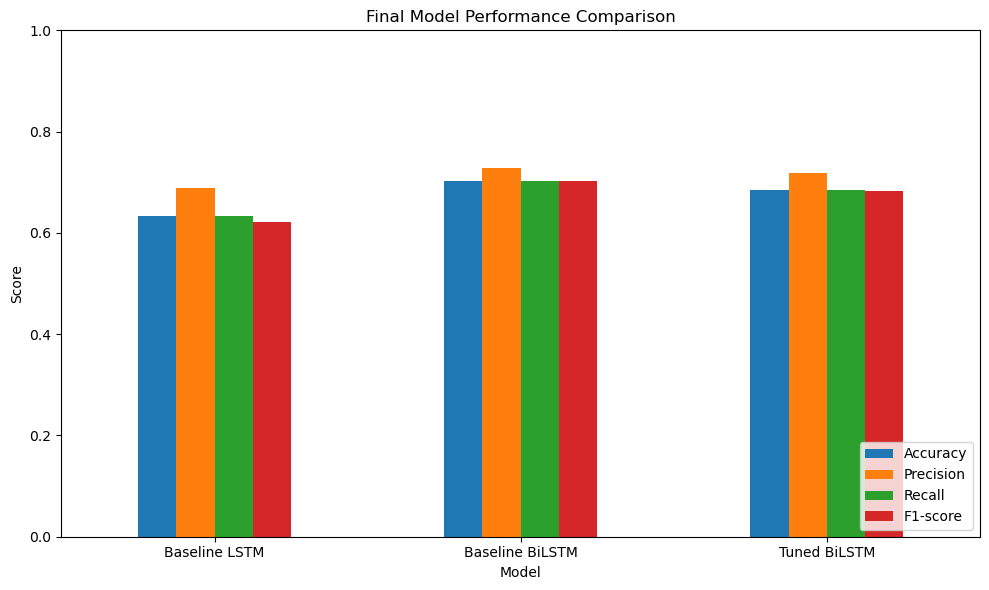

In [133]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

final_comparison_plot = final_model_comparison.set_index("Model")[metrics_to_plot]

final_comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [134]:
best_model_row = final_model_comparison.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

best_model_summary = pd.DataFrame({
    "Item": [
        "Best Model",
        "Test Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Result": [
        best_model_row["Model"],
        best_model_row["Test Loss"],
        best_model_row["Accuracy"],
        best_model_row["Precision"],
        best_model_row["Recall"],
        best_model_row["F1-score"]
    ]
})

best_model_summary

,Item,Result
0,Best Model,Baseline BiLSTM
1,Test Loss,0.8339
2,Accuracy,0.7031
3,Precision,0.7272
4,Recall,0.7031
5,F1-score,0.7028
